# Week 7 : Mini Project 2 (Not Graded)
<hr class=red-dashed-ruler>

## Set ups 
<hr class=red-dashed-ruler>

In [4]:
!jupyter nbconvert --to script ../utlities.ipynb

[NbConvertApp] Converting notebook ../utlities.ipynb to script
[NbConvertApp] Writing 4659 bytes to ..\utlities.py


<hr class=red-dashed-ruler>

This is a practice assignment and is not graded.
It is designed to reinforce learning and enhance understanding, the Submit option and completion indicators (green tick/status) are disabled.

 
**Learning Objectives Addressed:**
Understand core probability concepts and uncertainty.

Learn the role of probability distributions in modeling real-world variability.

Explore how variability impacts business decisions such as inventory planning and risk pooling.

Interpret probabilistic patterns in datasets for predictive and prescriptive decision-making.

 

These practice exercises are designed for self-learning and reinforcement. They will help you strengthen your understanding of fundamental Python concepts through practical application.

<hr class=red-dashed-ruler>

**Understand the Scenario**

You are analyzing survey responses to understand learner preferences.
Your task is to compute:

Basic, marginal, joint, and conditional probabilities

Expected values

Gender-wise comparisons

Independence checks

Visualizations of preference patterns

These questions mirror real-world survey analytics and behavioral insights.

<hr class=red-dashed-ruler>

## Initial Steps

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

df=pd.read_csv("data/Survey.csv")
print(df.head())

<hr class=red-dashed-ruler>

## Mini Project 2 – Learning Preferences: Questions

### Q1 : What is the probability that a respondent prefers Online classes?

In [ ]:
df.Prefers_Online.mean()

<hr class=red-dashed-ruler>

### Q2 : What is the probability that a respondent prefers both Weekend and Online classes?

In [ ]:
df['weekend_online'] = (df['Prefers_Online'] == 1 ) &  (df['Prefers_Weekend'] == 1)

In [ ]:
df['weekend_online'].mean()

In [ ]:
((df['Prefers_Online'] == 1) & (df['Prefers_Weekend'] == 1)).mean()

In [ ]:
type(((df['Prefers_Online'] == 1) & (df['Prefers_Weekend'] == 1)))

<hr class=red-dashed-ruler>

### Q3 : What is P(Online | Weekend) — the probability of preferring Online given that the respondent prefers Weekend?

Method 1

In [ ]:

p_weekend = df.Prefers_Weekend.mean()
p_weekend_and_online = ((df['Prefers_Online'] == 1) & (df['Prefers_Weekend'] == 1)).mean()
p_online_given_weekend = p_weekend_and_online/p_weekend
print(p_online_given_weekend)

Another way

In [ ]:
df.loc[ df['Prefers_Weekend'] == 1, 'Prefers_Online'].mean()

<hr class=red-dashed-ruler>

### Q4 : Calculate the marginal probabilities for each preference category.


Marginal probability means:
The probability of a single variable occurring, ignoring all other variables.

#### Marginal probabilities

In [ ]:
p_online = df['Prefers_Online'].mean()
p_weekend = df['Prefers_Weekend'].mean()

print("P(Prefers Online):", p_online)
print("P(Prefers Weekend):", p_weekend)

<hr class=red-dashed-ruler>

### Q5 : Test independence: Are Online and Weekend preferences independent?

Two events are independent if: 𝑃(Online AND Weekend) =𝑃(Online)×𝑃(Weekend)


In [30]:
p_online = df['Prefers_Online'].mean()
p_weekend = df['Prefers_Weekend'].mean()

# Joint probability
p_both = ((df['Prefers_Online'] == 1) & 
          (df['Prefers_Weekend'] == 1)).mean()

print("P(Online):", p_online)
print("P(Weekend):", p_weekend)
print("P(Online AND Weekend):", p_both)
print("P(Online) * P(Weekend):", p_online * p_weekend)

P(Online): 0.71
P(Weekend): 0.56
P(Online AND Weekend): 0.39
P(Online) * P(Weekend): 0.3976


Conclusion : Since they are not exactly same, they are not indepedent.


<hr class=red-dashed-ruler>

### Q6 : Estimate the expected value of the Online preference.

Expected value is simply the proportion of users who prefer online.

In [34]:
expected_online = df['Prefers_Online'].mean()

print("Expected Value (Online Preference):", expected_online)

Expected Value (Online Preference): 0.71


<hr class=red-dashed-ruler>

### Q7 : Compare Male vs Female preferences for Online learning.

In [36]:
df

,RespondentID,Prefers_Online,Prefers_Weekend,Gender,weekend_online
0,1,0,0,Female,False
1,2,1,0,Female,False
2,3,1,1,Male,True
3,4,0,1,Female,False
4,5,1,0,Male,False
...,...,...,...,...,...
95,96,1,1,Female,True
96,97,0,0,Female,False
97,98,1,0,Female,False
98,99,1,1,Male,True


In [38]:
df.groupby("Gender").size()

Gender
Female    48
Male      47
Other      5
dtype: int64

In [40]:
df.groupby("Gender").Prefers_Online.mean()

Gender
Female    0.708333
Male      0.680851
Other     1.000000
Name: Prefers_Online, dtype: float64

70% of Female and 68% of Male prefers online.

**Another way**

In [41]:
pd.crosstab(df['Gender'], df['Prefers_Online'], normalize='index')

Prefers_Online,0,1
Gender,,
Female,0.291667,0.708333
Male,0.319149,0.680851
Other,0.000000,1.000000


<hr class=red-dashed-ruler>

### Q8 : Construct a joint frequency table for Online and Weekend preferences.

A joint frequency table shows how often two variables occur together.
Instead of looking at one variable at a time (like marginal frequency), it shows combinations.

This can be done using Cross Tabulation functions in Panda.

In [50]:
pd.crosstab(df['Prefers_Online'], df['Prefers_Weekend'], normalize=True)

Prefers_Weekend,0,1
Prefers_Online,,
0,0.12,0.17
1,0.32,0.39


<hr class=red-dashed-ruler>

### Q9 : Plot the gender distribution of preferences using an appropriate chart (e.g., bar or stacked column).

In [47]:
gener_dist=pd.crosstab(df['Gender'], df['Prefers_Online'], normalize='index')

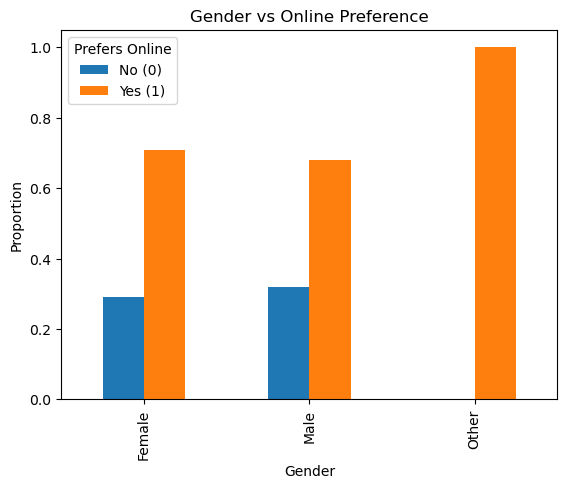

In [58]:
import matplotlib.pyplot as plt

ax = gener_dist.plot(kind='bar')

ax.set_title("Gender vs Online Preference")
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion")
plt.legend(title="Prefers Online", labels=['No (0)', 'Yes (1)'])
plt.show()


Now, Multiple variables. 

In [86]:
gender_multi_dist

Prefers_Online         No                 Yes          
Prefers_Weekend        No       Yes        No       Yes
Gender                                                 
Female           0.104167  0.187500  0.333333  0.375000
Male             0.148936  0.170213  0.276596  0.404255
Other            0.000000  0.000000  0.600000  0.400000

In [67]:
gender_multi_dist.rename(
    index={0: 'No', 1: 'Yes'},
    columns={0: 'No', 1: 'Yes'},
    inplace=True
)

In [68]:
gender_multi_dist

Prefers_Online         No                 Yes          
Prefers_Weekend        No       Yes        No       Yes
Gender                                                 
Female           0.104167  0.187500  0.333333  0.375000
Male             0.148936  0.170213  0.276596  0.404255
Other            0.000000  0.000000  0.600000  0.400000

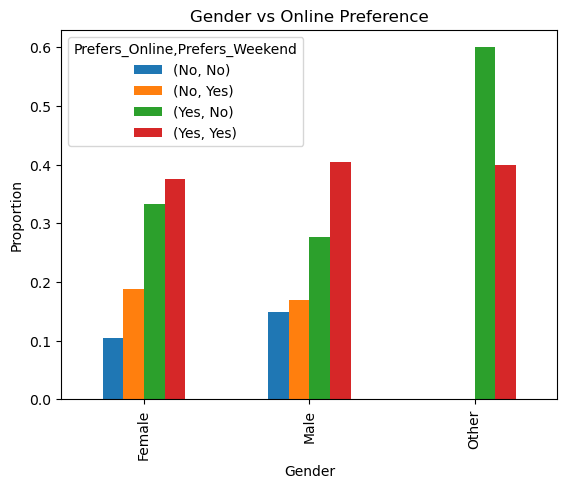

In [70]:
ax = gender_multi_dist.plot(kind='bar')
ax.set_title("Gender vs Online Preference")
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion")
plt.show()

<hr class=red-dashed-ruler>

### Q10 : What is P(Female and prefers Online)?

In [81]:
p_female_and_online = ((df['Gender'] == "Female") & (df['Prefers_Online'] == 1)).mean()
print(p_female_and_online)

0.34


<hr class=red-dashed-ruler>

### Q11 : Estimate P(not preferring Online or Weekend).

In [82]:
p_not_Online_or_Weekend = ((df['Prefers_Online'] == 0) | (df['Prefers_Weekend'] == 0)).mean()
print(p_not_Online_or_Weekend )

0.61


<hr class=red-dashed-ruler>

### Q12: What proportion of “Other” gender respondents prefer Online?

In [89]:
df[df['Gender'] == "Other"].Prefers_Online.mean()

np.float64(1.0)

Answer is 100%

<hr class=red-dashed-ruler>

### Q13 : Compute conditional probability P(Weekend | Female).

In [97]:

# p_weekend = df.Prefers_Weekend.mean()
# p_weekend_and_online = ((df['Prefers_Online'] == 1) & (df['Prefers_Weekend'] == 1)).mean()
# p_online_given_weekend = p_weekend_and_online/p_weekend
# print(p_online_given_weekend)

# p_weekend_given_female = p_weekend_and_female/p_female
p_female = (df['Gender'] == "Female").mean()
print("Probability of Being Female :", p_female)
p_weekend_and_female = ((df['Gender'] == "Female") & (df['Prefers_Weekend'] == 1)).mean()
print("Probability of Being Female and Prefers Weekend :", p_weekend_and_female)
p_weekend_given_female = p_weekend_and_female/p_female
print("Probability of Weekend preference given Female :", p_weekend_given_female)



Probability of Being Female : 0.48
Probability of Being Female and Prefers Weekend : 0.27
Probability of Weekend preference given Female : 0.5625000000000001


Another way

In [98]:
df.loc[ df['Gender'] == "Female", 'Prefers_Weekend'].mean()

np.float64(0.5625)

<hr class=red-dashed-ruler>

### Q14: Use dataset to simulate event trees.

An event tree represents how probabilities flow step-by-step.

Example : 
Start
├── Female (P=0.6)
│   ├── Online=1 (P=0.5) 
│   │   ├── Weekend=1 (P=0.7)
│   │   └── Weekend=0 (P=0.3)
│   └── Online=0 (P=0.5)
│       ├── Weekend=1 (P=0.4
│       └── Weekend=0 (P=0.6)
│
└── Male (P=0.4)
    ├── Online=1 (P=0.7)
    │   ├── Weekend=1 (P=0.8)
    │   └── Weekend=0 (P=0.2)
    └── Online=0 (P=0.3)
        ├── Weekend=1 (P=0.5)
        └── Weekend=0 (P=0.5)

In [102]:
# Step 1: P(Gender)
p_gender = df['Gender'].value_counts(normalize=True)

# Step 2: P(Online | Gender)
p_online_given_gender = df.groupby('Gender')['Prefers_Online'].mean()

# Step 3: P(Weekend | Gender, Online)
p_weekend_given_both = (
    df.groupby(['Gender', 'Prefers_Online'])['Prefers_Weekend']
    .mean()
)

print("P(Gender):\n", p_gender)
print("\nP(Online | Gender):\n", p_online_given_gender)
print("\nP(Weekend | Gender, Online):\n", p_weekend_given_both)

P(Gender):
 Gender
Female    0.48
Male      0.47
Other     0.05
Name: proportion, dtype: float64

P(Online | Gender):
 Gender
Female    0.708333
Male      0.680851
Other     1.000000
Name: Prefers_Online, dtype: float64

P(Weekend | Gender, Online):
 Gender  Prefers_Online
Female  0                 0.642857
        1                 0.529412
Male    0                 0.533333
        1                 0.593750
Other   1                 0.400000
Name: Prefers_Weekend, dtype: float64


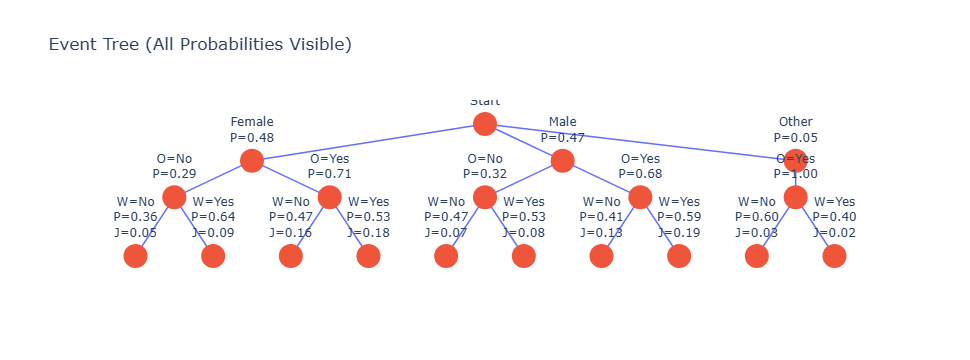

In [114]:
import pandas as pd
import plotly.graph_objects as go

# --- Step 1: Compute probabilities ---
p_gender = df['Gender'].value_counts(normalize=True)
p_online = df.groupby('Gender')['Prefers_Online'].mean()
p_weekend = df.groupby(['Gender', 'Prefers_Online'])['Prefers_Weekend'].mean()

def yn(x):
    return "Yes" if x == 1 else "No"

# --- Step 2: Build paths ---
paths = []

for gender in p_gender.index:
    for online in sorted(df['Prefers_Online'].dropna().unique()):
        if gender not in p_online:
            continue
        
        if (gender, online) in p_weekend:
            for weekend in sorted(df['Prefers_Weekend'].dropna().unique()):
                paths.append((gender, online, weekend))

# --- Step 3: Assign X positions ---
n_paths = len(paths)
x_positions = {path: (i + 1) / (n_paths + 1) for i, path in enumerate(paths)}

nodes = {}
edges = []
labels = {}

# Root
nodes["Start"] = (0.5, 1.0)
labels["Start"] = "Start"

gender_x = {}
online_x = {}

# --- Leaf nodes (Weekend) ---
for (gender, online, weekend), x in x_positions.items():
    
    prob_w = p_weekend[(gender, online)]
    prob_cond = prob_w if weekend == 1 else (1 - prob_w)
    
    prob_joint = (
        p_gender[gender] *
        (p_online[gender] if online == 1 else (1 - p_online[gender])) *
        prob_cond
    )
    
    w_key = f"{gender}_{online}_{weekend}"
    nodes[w_key] = (x, 0.1)
    
    labels[w_key] = (
        f"W={yn(weekend)}"
        f"<br>P={prob_cond:.2f}"
        f"<br>J={prob_joint:.2f}"
    )
    
    gender_x.setdefault(gender, []).append(x)
    online_x.setdefault((gender, online), []).append(x)

# --- Online nodes ---
for (gender, online), xs in online_x.items():
    x = sum(xs) / len(xs)
    
    prob_online = p_online[gender] if online == 1 else (1 - p_online[gender])
    
    o_key = f"{gender}_{online}"
    nodes[o_key] = (x, 0.5)
    
    labels[o_key] = (
        f"O={yn(online)}"
        f"<br>P={prob_online:.2f}"
    )
    
    for weekend in sorted(df['Prefers_Weekend'].dropna().unique()):
        w_key = f"{gender}_{online}_{weekend}"
        if w_key in nodes:
            edges.append((o_key, w_key))

# --- Gender nodes ---
for gender, xs in gender_x.items():
    x = sum(xs) / len(xs)
    
    g_key = f"G_{gender}"
    nodes[g_key] = (x, 0.75)
    
    labels[g_key] = (
        f"{gender}"
        f"<br>P={p_gender[gender]:.2f}"
    )
    
    for online in sorted(df['Prefers_Online'].dropna().unique()):
        o_key = f"{gender}_{online}"
        if o_key in nodes:
            edges.append((g_key, o_key))
    
    edges.append(("Start", g_key))

# --- Step 4: Plot ---
node_x = [nodes[k][0] for k in nodes]
node_y = [nodes[k][1] for k in nodes]
node_text = [labels[k] for k in nodes]

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    text=node_text,
    textposition="top center",
    marker=dict(size=24)
)

# Edges
edge_x, edge_y = [], []

for src, dst in edges:
    x0, y0 = nodes[src]
    x1, y1 = nodes[dst]
    
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=1.5),
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title="Event Tree (All Probabilities Visible)",
    showlegend=False,
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor='white'
)

fig.show()

In your tree, J = Joint Probability

J=P(Female)×P(Online∣Female)×P(Weekend∣Female, Online)

<hr class=red-dashed-ruler>

### Q15: Discuss sample bias that could affect results.

##### ✅ What is Sample Bias?

**Sample bias** happens when your dataset is **not representative of the real population** you want to study.

👉 Result: Your conclusions (probabilities, trends, insights) become **misleading**.

---

##### 📊 In Your Survey Context

Your dataset includes:

* Gender
* Online preference
* Weekend preference

Now imagine:
👉 Who actually responded to this survey?

That’s where bias creeps in.

---

##### ⚠️ Key Types of Sample Bias (Relevant Here)

---

###### 1. **Selection Bias**

If your data is collected from a **specific group only**

Example:

* Survey shared only in an **IT company**
* Or among **students**

👉 Then:

* Online preference will appear **artificially high**

---

###### 2. **Self-Selection Bias**

Only people who **choose to respond** are included

Example:

* People interested in online learning are **more likely to respond**

👉 Result:

* Overestimation of online preference

---

###### 3. **Undercoverage Bias**

Some groups are **missing or underrepresented**

Example:

* Elderly people not included
* Rural population missing

👉 Result:

* Biased toward tech-savvy users

---

###### 4. **Gender Imbalance**

Check:

```python
df['Gender'].value_counts(normalize=True)
```

👉 If:

* 80% Female, 20% Male

Then:

* Overall probabilities are **skewed toward female behavior**

---

###### 5. **Small Sample Size**

If dataset is small:

* Random variation dominates
* Results may not generalize

---

##### 🧠 Why This Matters (Critical Insight)

All your calculations:

* Marginal probability
* Joint probability
* Independence
* Event trees

👉 Are **only valid for this dataset**, NOT necessarily real-world truth

---

##### 🔍 Example of Misleading Insight

You might conclude:

> “70% prefer online learning”

But if:

* Data = mostly young professionals

👉 Real population might be:

* Only 40%

---

##### 🧠 Architect-Level Thinking

In real systems, we ask:

1. **Who is missing?**
2. **Who is overrepresented?**
3. **How was data collected?**

---

##### 🚀 How to Mitigate Bias

* Ensure **diverse sampling**
* Use **stratified sampling**
* Weight data:

```python
# Example concept
df['weight'] = ...
```

* Validate against external benchmarks

---

##### 📎 Final Takeaway

> Your model is only as good as your data.

Even perfect analysis on biased data → **wrong conclusions**

---


<hr class=red-dashed-ruler>